# Five Emotion Models — Colab Comparison

This notebook runs five pretrained Transformer emotion classifiers on `emotion_test_dataset.csv`.

Models:
1. `SamLowe/roberta-base-go_emotions`
2. `j-hartmann/emotion-english-distilroberta-base`
3. `cirimus/modernbert-base-go-emotions`
4. `cirimus/modernbert-large-go-emotions`
5. `j-hartmann/emotion-english-roberta-large`

These checkpoints are listed in the current Hugging Face model catalog for English emotion classification. citeturn0search2turn0search4

In [1]:
!pip -q install transformers torch scikit-learn pandas matplotlib seaborn accelerate

## 1. Upload `emotion_test_dataset.csv`

In [2]:
from google.colab import files
uploaded = files.upload()
filename = next(iter(uploaded))
print("Using:", filename)

Saving emotion_test_dataset.csv to emotion_test_dataset.csv
Using: emotion_test_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv(filename)
TEXT_COL = "text"
LABEL_COL = "emotion"

assert TEXT_COL in df.columns
assert LABEL_COL in df.columns

df = df[[TEXT_COL, LABEL_COL]].dropna().copy()
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip().str.lower()

print("Shape:", df.shape)
display(df.head())
print("\nLabels:")
display(df[LABEL_COL].value_counts())

Shape: (50, 2)


,text,emotion
0,I am so happy that I finally achieved my goal!,joy
1,She cried after hearing the sad news.,sadness
2,He was furious when he discovered what happened.,anger
3,I am terrified of being alone in this place.,fear
4,Wow! I never expected this surprise.,surprise



Labels:


,count
emotion,
fear,6
joy,5
sadness,4
anger,4
surprise,4
disgust,3
gratitude,3
love,2
excitement,2


## 2. Define the five models

In [4]:
MODEL_CONFIGS = {
    "RoBERTa-GoEmotions": "SamLowe/roberta-base-go_emotions",
    "DistilRoBERTa-Emotion": "j-hartmann/emotion-english-distilroberta-base",
    "ModernBERT-GoEmotions": "cirimus/modernbert-base-go-emotions",
    "ModernBERT-Large-GoEmotions": "cirimus/modernbert-large-go-emotions",
    "RoBERTa-Large-Emotion": "j-hartmann/emotion-english-roberta-large"
}

for name, checkpoint in MODEL_CONFIGS.items():
    print(name, "->", checkpoint)

RoBERTa-GoEmotions -> SamLowe/roberta-base-go_emotions
DistilRoBERTa-Emotion -> j-hartmann/emotion-english-distilroberta-base
ModernBERT-GoEmotions -> cirimus/modernbert-base-go-emotions
ModernBERT-Large-GoEmotions -> cirimus/modernbert-large-go-emotions
RoBERTa-Large-Emotion -> j-hartmann/emotion-english-roberta-large


## 3. Load and run the models

Important: different checkpoints can use different emotion taxonomies. The notebook therefore reports both predictions and an exact-label evaluation. Do not treat scores from incompatible label spaces as a rigorous benchmark.

In [5]:
import torch
from transformers import pipeline
from tqdm.auto import tqdm

device = 0 if torch.cuda.is_available() else -1
print("Device:", "GPU" if device == 0 else "CPU")

def normalize_label(label):
    return str(label).lower().replace("-", "_").replace(" ", "_")

def run_model(checkpoint, texts):
    clf = pipeline(
        "text-classification",
        model=checkpoint,
        top_k=None,
        device=device
    )
    preds, confs = [], []
    for text in tqdm(texts, leave=False):
        output = clf(text, truncation=True)[0]
        best = max(output, key=lambda x: x["score"])
        preds.append(normalize_label(best["label"]))
        confs.append(float(best["score"]))
    return preds, confs

all_results = {}

for model_name, checkpoint in MODEL_CONFIGS.items():
    print("\n" + "="*70)
    print(model_name)
    print(checkpoint)
    print("="*70)
    try:
        preds, confs = run_model(checkpoint, df[TEXT_COL].tolist())
        df[model_name + "_prediction"] = preds
        df[model_name + "_confidence"] = confs
        all_results[model_name] = "OK"
        print("Completed.")
    except Exception as e:
        print("FAILED:", repr(e))
        df[model_name + "_prediction"] = None
        df[model_name + "_confidence"] = None
        all_results[model_name] = repr(e)

print(all_results)

Device: GPU

RoBERTa-GoEmotions
SamLowe/roberta-base-go_emotions


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Completed.
{'RoBERTa-GoEmotions': 'OK', 'DistilRoBERTa-Emotion': 'OK', 'ModernBERT-GoEmotions': 'OK', 'ModernBERT-Large-GoEmotions': 'OK', 'RoBERTa-Large-Emotion': 'OK'}


## 4. View all predictions

In [6]:
prediction_cols = [m + "_prediction" for m in MODEL_CONFIGS]
display(df[[TEXT_COL, LABEL_COL] + prediction_cols])

,text,emotion,RoBERTa-GoEmotions_prediction,DistilRoBERTa-Emotion_prediction,ModernBERT-GoEmotions_prediction,ModernBERT-Large-GoEmotions_prediction,RoBERTa-Large-Emotion_prediction
0,I am so happy that I finally achieved my goal!,joy,joy,joy,joy,joy,joy
1,She cried after hearing the sad news.,sadness,sadness,sadness,sadness,sadness,sadness
2,He was furious when he discovered what happened.,anger,neutral,anger,anger,anger,anger
3,I am terrified of being alone in this place.,fear,fear,fear,fear,fear,fear
4,Wow! I never expected this surprise.,surprise,surprise,surprise,surprise,surprise,surprise
5,She felt disgusted by the rotten food.,disgust,disgust,disgust,disgust,disgust,disgust
6,I love spending time with my family.,love,love,joy,love,love,joy
7,I am worried about what will happen tomorrow.,fear,nervousness,fear,nervousness,nervousness,fear
8,He smiled when he received the good news.,joy,joy,joy,joy,joy,joy
9,She felt completely hopeless after losing ever...,sadness,sadness,sadness,sadness,disappointment,sadness


## 5. Compare exact-label performance

In [7]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

rows = []

for model_name in MODEL_CONFIGS:
    pred_col = model_name + "_prediction"
    valid = df[pred_col].notna()

    y_true = df.loc[valid, LABEL_COL].map(normalize_label)
    y_pred = df.loc[valid, pred_col].map(normalize_label)

    if len(y_true):
        accuracy = accuracy_score(y_true, y_pred)
        macro_f1 = precision_recall_fscore_support(
            y_true, y_pred, average="macro", zero_division=0
        )[2]
        weighted_f1 = precision_recall_fscore_support(
            y_true, y_pred, average="weighted", zero_division=0
        )[2]
    else:
        accuracy = macro_f1 = weighted_f1 = np.nan

    rows.append({
        "model": model_name,
        "examples": len(y_true),
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values("macro_f1", ascending=False))

,model,examples,accuracy,macro_f1,weighted_f1
2,ModernBERT-GoEmotions,50,0.82,0.678222,0.831556
3,ModernBERT-Large-GoEmotions,50,0.80,0.634676,0.803238
0,RoBERTa-GoEmotions,50,0.76,0.570726,0.747111
1,DistilRoBERTa-Emotion,50,0.52,0.188732,0.394652
4,RoBERTa-Large-Emotion,50,0.52,0.187746,0.390729


## 6. Detailed classification reports

In [8]:
from sklearn.metrics import classification_report

for model_name in MODEL_CONFIGS:
    pred_col = model_name + "_prediction"
    valid = df[pred_col].notna()

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print(classification_report(
        df.loc[valid, LABEL_COL],
        df.loc[valid, pred_col],
        zero_division=0
    ))


RoBERTa-GoEmotions
                precision    recall  f1-score   support

    admiration       0.67      1.00      0.80         2
         anger       0.75      0.75      0.75         4
     annoyance       1.00      1.00      1.00         1
      approval       0.00      0.00      0.00         0
        caring       0.00      0.00      0.00         0
     confusion       1.00      1.00      1.00         1
disappointment       1.00      1.00      1.00         2
       disgust       1.00      0.67      0.80         3
 embarrassment       0.50      1.00      0.67         1
    excitement       1.00      1.00      1.00         2
          fear       1.00      0.67      0.80         6
     gratitude       1.00      1.00      1.00         3
          hope       0.00      0.00      0.00         1
      jealousy       0.00      0.00      0.00         1
           joy       0.80      0.80      0.80         5
          love       1.00      1.00      1.00         2
   nervousness       0.50  

## 7. Confusion matrix for each model

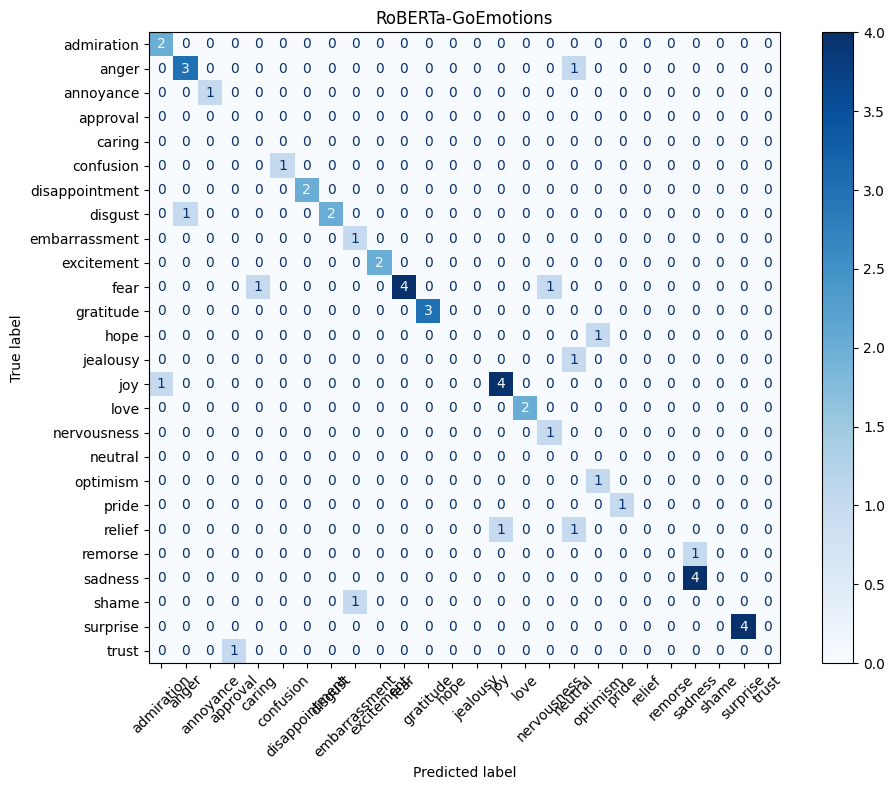

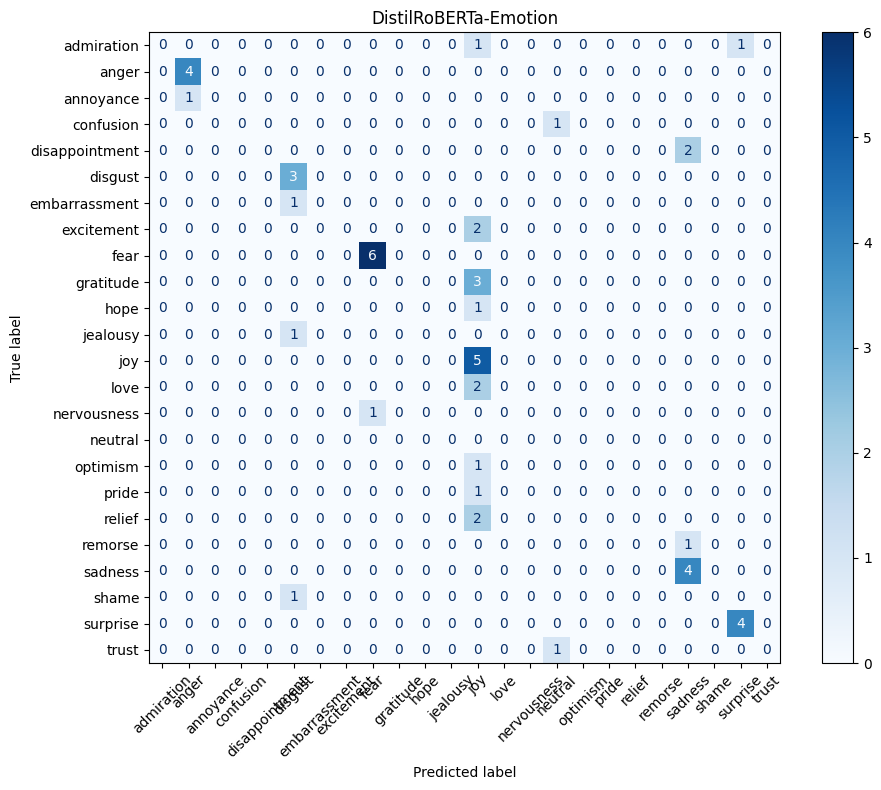

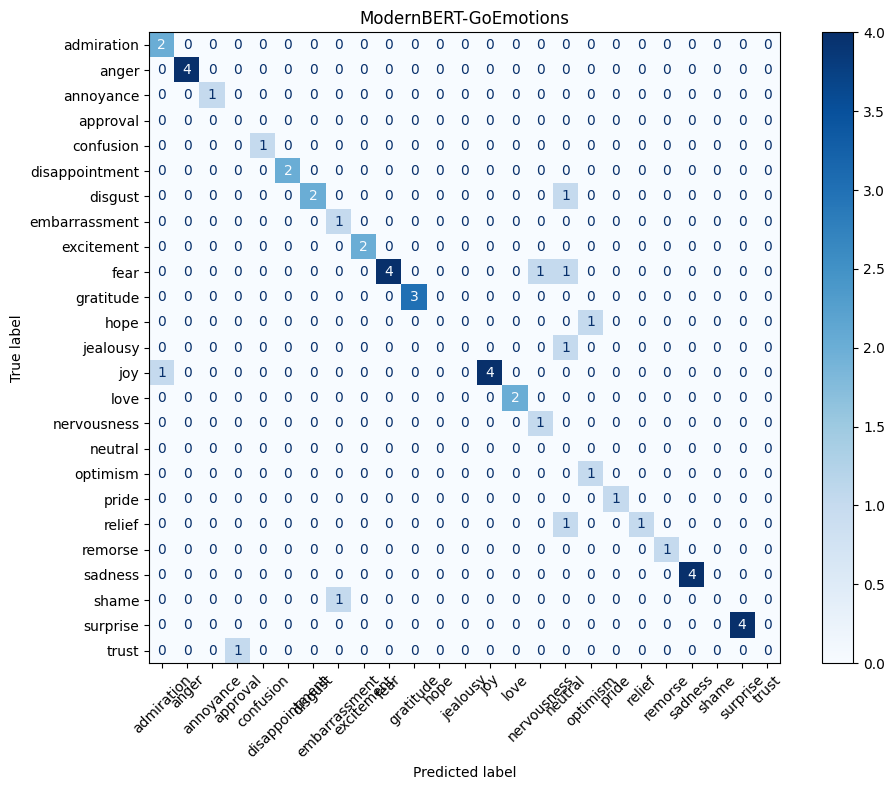

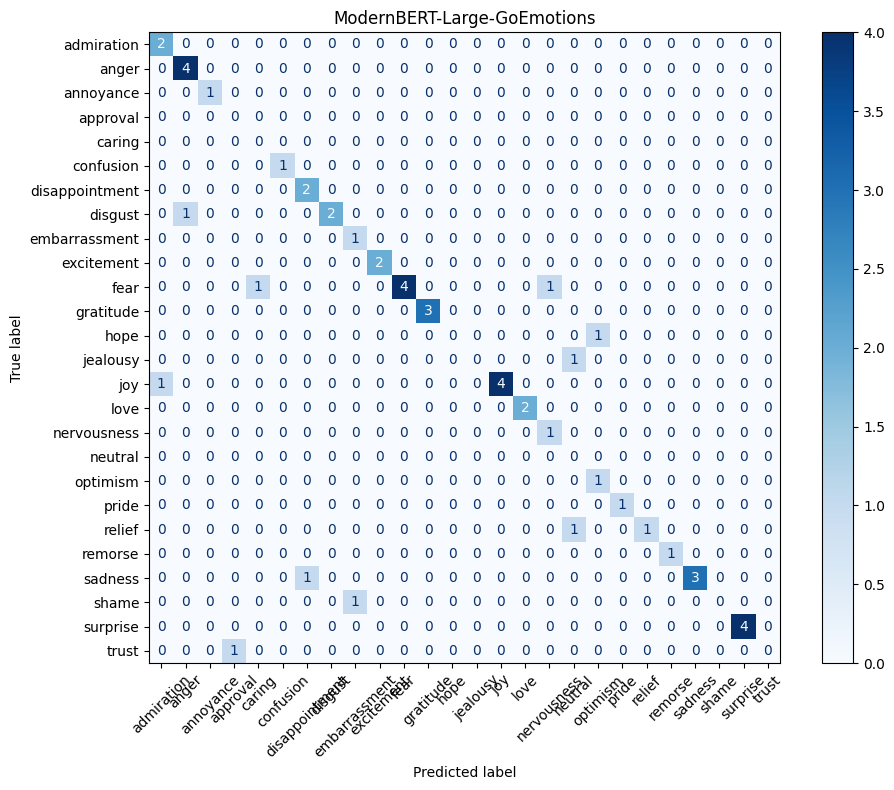

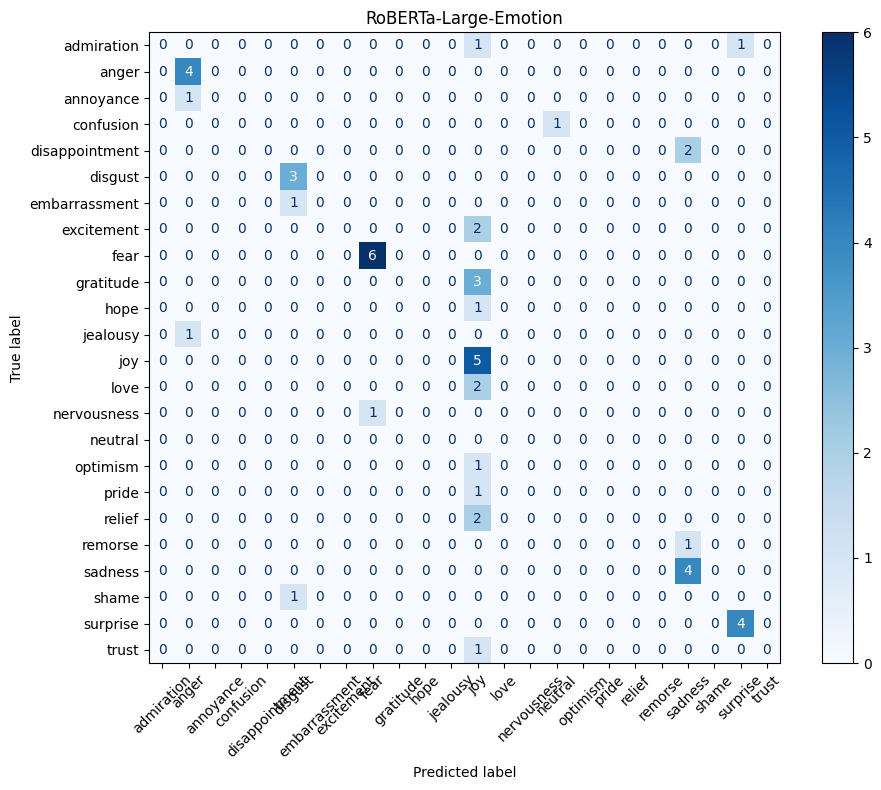

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name in MODEL_CONFIGS:
    pred_col = model_name + "_prediction"
    valid = df[pred_col].notna()

    fig, ax = plt.subplots(figsize=(10, 8))
    ConfusionMatrixDisplay.from_predictions(
        df.loc[valid, LABEL_COL],
        df.loc[valid, pred_col],
        xticks_rotation=45,
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(model_name)
    plt.tight_layout()
    plt.show()

## 8. Save results

In [10]:
predictions_file = "five_emotion_models_predictions.csv"
metrics_file = "five_emotion_models_metrics.csv"

df.to_csv(predictions_file, index=False)
metrics_df.to_csv(metrics_file, index=False)

print("Saved:", predictions_file)
print("Saved:", metrics_file)

Saved: five_emotion_models_predictions.csv
Saved: five_emotion_models_metrics.csv


In [11]:
from google.colab import files
files.download(predictions_file)
files.download(metrics_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Research recommendation

For your actual literature survey, use a larger held-out emotion-labeled dataset with the same emotion taxonomy for all models. Report macro-F1, per-class F1, confusion matrices, inference time, and model size.

Your current 50-row CSV is useful for checking the pipeline, but it is too small to establish a reliable general benchmark.